# Sales Analytics Dashboard Challenge

A company has sales data for 500 transactions. Your task is to clean, analyze, and generate insights from the data.

In [2]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 500

df = pd.DataFrame({
    "Order_ID": np.arange(1001, 1001+n),
    "Product": np.random.choice(["Laptop", "Mouse", "Keyboard", "Monitor"], n),
    "Category": np.random.choice(["Electronics", "Accessories"], n),
    "Price": np.random.randint(1000, 100000, n),
    "Quantity": np.random.randint(1, 10, n),
    "City": np.random.choice(["Lahore", "Karachi", "Islamabad", "Peshawar"], n),
    "Discount": np.random.choice([0, 5, 10, 15, np.nan], n),
    "Rating": np.random.choice([1, 2, 3, 4, 5, np.nan], n)
})

# Add duplicate rows
df = pd.concat([df, df.iloc[:10]], ignore_index=True)

# Add some missing values
df.loc[np.random.choice(df.index, 20), "Price"] = np.nan

print(df.head())

   Order_ID   Product     Category    Price  Quantity     City  Discount  \
0      1001  Keyboard  Electronics  48605.0         2   Lahore      10.0   
1      1002   Monitor  Electronics  39088.0         5   Lahore      15.0   
2      1003    Laptop  Electronics  79752.0         1   Lahore       5.0   
3      1004  Keyboard  Accessories  56284.0         7   Lahore       NaN   
4      1005  Keyboard  Electronics  58043.0         1  Karachi       0.0   

   Rating  
0     3.0  
1     1.0  
2     NaN  
3     3.0  
4     NaN  


# Tasks
Data Inspection<br>
Display first 10 rows.<br>
Show shape of dataset.<br>
Display column names.<br>
Check data types.<br>
Get summary statistics.

In [3]:
print("ist ten rows of the dataframe : \n",df.head(10))
print("\n\n shape of the dataset",df.shape)
print("\n\n" )
print("displaying columns names : ",df.columns)
print("\n\n" )

print("data type of the dataframe " ,df.dtypes)
print("\n\n" )
print("summary statistics : ",df.describe())

ist ten rows of the dataframe : 
    Order_ID   Product     Category    Price  Quantity      City  Discount  \
0      1001  Keyboard  Electronics  48605.0         2    Lahore      10.0   
1      1002   Monitor  Electronics  39088.0         5    Lahore      15.0   
2      1003    Laptop  Electronics  79752.0         1    Lahore       5.0   
3      1004  Keyboard  Accessories  56284.0         7    Lahore       NaN   
4      1005  Keyboard  Electronics  58043.0         1   Karachi       0.0   
5      1006   Monitor  Electronics  36547.0         4    Lahore       5.0   
6      1007    Laptop  Accessories  98007.0         9    Lahore       NaN   
7      1008    Laptop  Electronics  83844.0         1  Peshawar       5.0   
8      1009  Keyboard  Accessories  28532.0         4   Karachi      15.0   
9      1010     Mouse  Accessories  35349.0         6   Karachi      15.0   

   Rating  
0     3.0  
1     1.0  
2     NaN  
3     3.0  
4     NaN  
5     5.0  
6     4.0  
7     NaN  
8     2.0 

# Missing Value Handling
Count missing values per column.<br>
Replace missing discounts with 0.<br>
Fill missing ratings using median.<br>
Fill missing prices using mean price.

In [4]:
miss_val_per_col = df.isnull().sum(axis=0)
print(miss_val_per_col)
print("----------------------------------")
miss_dis_with_zero = df["Discount"].fillna(0)
print(miss_dis_with_zero)
rating_median = df["Rating"].median()
miss_rat_with_zero = df["Rating"].fillna(rating_median)
print(miss_rat_with_zero)
mean_price = df["Price"].mean()
miss_price_with_mean = df["Price"].fillna(mean_price)
print(miss_price_with_mean)


Order_ID      0
Product       0
Category      0
Price        20
Quantity      0
City          0
Discount    110
Rating       94
dtype: int64
----------------------------------
0      10.0
1      15.0
2       5.0
3       0.0
4       0.0
       ... 
505     5.0
506     0.0
507     5.0
508    15.0
509    15.0
Name: Discount, Length: 510, dtype: float64
0      3.0
1      1.0
2      3.0
3      3.0
4      3.0
      ... 
505    5.0
506    4.0
507    3.0
508    2.0
509    3.0
Name: Rating, Length: 510, dtype: float64
0      48605.0
1      39088.0
2      79752.0
3      56284.0
4      58043.0
        ...   
505    36547.0
506    98007.0
507    83844.0
508    28532.0
509    35349.0
Name: Price, Length: 510, dtype: float64


# Duplicate Handling
Find duplicate rows.
<br>
Remove duplicates.


In [5]:
duplicate_rows = df[df.duplicated()]
print(duplicate_rows)
Remove_dup_rows = df.drop_duplicates()
print(Remove_dup_rows)

     Order_ID   Product     Category    Price  Quantity      City  Discount  \
500      1001  Keyboard  Electronics  48605.0         2    Lahore      10.0   
501      1002   Monitor  Electronics  39088.0         5    Lahore      15.0   
502      1003    Laptop  Electronics  79752.0         1    Lahore       5.0   
503      1004  Keyboard  Accessories  56284.0         7    Lahore       NaN   
505      1006   Monitor  Electronics  36547.0         4    Lahore       5.0   
506      1007    Laptop  Accessories  98007.0         9    Lahore       NaN   
507      1008    Laptop  Electronics  83844.0         1  Peshawar       5.0   
508      1009  Keyboard  Accessories  28532.0         4   Karachi      15.0   
509      1010     Mouse  Accessories  35349.0         6   Karachi      15.0   

     Rating  
500     3.0  
501     1.0  
502     NaN  
503     3.0  
505     5.0  
506     4.0  
507     NaN  
508     2.0  
509     NaN  
     Order_ID   Product     Category    Price  Quantity      City  Di

# Feature Engineering
Create a new column:
<br>
Revenue = Price * Quantity
<br>Final_Price = Price - (Price * Discount / 100)<br>
If Revenue > 100000 then "Yes" else "No".



In [6]:
df["Revenue"] = df["Price"] * df["Quantity"]
df["final_price"] = df["Price"] - (df["Price"] * df["Discount"]/100)
df["high_sale"] = np.where(df["Revenue"] > 100000,"yes","no")
df


,Order_ID,Product,Category,Price,Quantity,City,Discount,Rating,Revenue,final_price,high_sale
0,1001,Keyboard,Electronics,48605.0,2,Lahore,10.0,3.0,97210.0,43744.50,no
1,1002,Monitor,Electronics,39088.0,5,Lahore,15.0,1.0,195440.0,33224.80,yes
2,1003,Laptop,Electronics,79752.0,1,Lahore,5.0,NaN,79752.0,75764.40,no
3,1004,Keyboard,Accessories,56284.0,7,Lahore,NaN,3.0,393988.0,NaN,yes
4,1005,Keyboard,Electronics,58043.0,1,Karachi,0.0,NaN,58043.0,58043.00,no
...,...,...,...,...,...,...,...,...,...,...,...
505,1006,Monitor,Electronics,36547.0,4,Lahore,5.0,5.0,146188.0,34719.65,yes
506,1007,Laptop,Accessories,98007.0,9,Lahore,NaN,4.0,882063.0,NaN,yes
507,1008,Laptop,Electronics,83844.0,1,Peshawar,5.0,NaN,83844.0,79651.80,no
508,1009,Keyboard,Accessories,28532.0,4,Karachi,15.0,2.0,114128.0,24252.20,yes


# Filtering
Show all Laptop sales.<br>
Show transactions where Revenue > 200000.<br>
Show sales from Islamabad with Rating > 4.


In [7]:
laptop_sale = df[df["Product"] == "Laptop"]
print(laptop_sale,"\n\n")
print("\n\n")
revenue_transication = df[df["Revenue"] > 200000]
print(revenue_transication)
df[(df["City"] == "Islamabad") & (df["Rating"] > 4)]


     Order_ID Product     Category    Price  Quantity       City  Discount  \
2        1003  Laptop  Electronics  79752.0         1     Lahore       5.0   
6        1007  Laptop  Accessories  98007.0         9     Lahore       NaN   
7        1008  Laptop  Electronics  83844.0         1   Peshawar       5.0   
15       1016  Laptop  Electronics  51990.0         7    Karachi      10.0   
21       1022  Laptop  Electronics  57570.0         3  Islamabad       0.0   
..        ...     ...          ...      ...       ...        ...       ...   
494      1495  Laptop  Accessories  20956.0         4    Karachi      15.0   
498      1499  Laptop  Accessories  95270.0         1    Karachi      15.0   
502      1003  Laptop  Electronics  79752.0         1     Lahore       5.0   
506      1007  Laptop  Accessories  98007.0         9     Lahore       NaN   
507      1008  Laptop  Electronics  83844.0         1   Peshawar       5.0   

     Rating   Revenue  final_price high_sale  
2       NaN   79

,Order_ID,Product,Category,Price,Quantity,City,Discount,Rating,Revenue,final_price,high_sale
10,1011,Keyboard,Electronics,46445.0,6,Islamabad,15.0,5.0,278670.0,39478.25,yes
13,1014,Keyboard,Accessories,50407.0,7,Islamabad,NaN,5.0,352849.0,NaN,yes
28,1029,Monitor,Accessories,63292.0,1,Islamabad,5.0,5.0,63292.0,60127.40,no
48,1049,Mouse,Accessories,61100.0,7,Islamabad,5.0,5.0,427700.0,58045.00,yes
58,1059,Keyboard,Accessories,33201.0,1,Islamabad,NaN,5.0,33201.0,NaN,no
60,1061,Keyboard,Accessories,14456.0,2,Islamabad,0.0,5.0,28912.0,14456.00,no
69,1070,Mouse,Electronics,71080.0,7,Islamabad,0.0,5.0,497560.0,71080.00,yes
74,1075,Laptop,Electronics,8239.0,7,Islamabad,15.0,5.0,57673.0,7003.15,no
110,1111,Monitor,Electronics,62886.0,7,Islamabad,15.0,5.0,440202.0,53453.10,yes
144,1145,Monitor,Accessories,25071.0,1,Islamabad,NaN,5.0,25071.0,NaN,no


# Sorting and groupby
    18.Sort by Revenue descending.
    19. Show top 10 highest revenue transactions.

    20. Calculate average price per product.
    21. Calculate total revenue per city.
    22. Calculate total quantity sold per category.
    23. Find highest revenue product.


In [8]:
sort_by_rev = df.sort_values(by=["Revenue"],ascending=False).head(10)
print(sort_by_rev)
# calculate average price per product
avg_product = df.groupby("Product")["Price"].agg(["mean"])
print(avg_product)
# calcualte total revenue per city
total_revenue_city = df.groupby("City")["Revenue"].sum()
print(total_revenue_city)
# calcualte total quantity sold per categor
quantity_sold_per_category = df.groupby("Category")["Quantity"].sum()
print(quantity_sold_per_category)
# find highest revenue product
highest_revenue_pro = df.groupby("Product")["Revenue"].max().idxmax()
highest_revenue_pro

     Order_ID   Product     Category    Price  Quantity       City  Discount  \
279      1280     Mouse  Electronics  98579.0         9   Peshawar       0.0   
506      1007    Laptop  Accessories  98007.0         9     Lahore       NaN   
6        1007    Laptop  Accessories  98007.0         9     Lahore       NaN   
211      1212  Keyboard  Accessories  91825.0         9  Islamabad      15.0   
333      1334  Keyboard  Accessories  88388.0         9   Peshawar       0.0   
353      1354   Monitor  Electronics  94709.0         8    Karachi       5.0   
163      1164   Monitor  Accessories  94229.0         8   Peshawar      15.0   
300      1301    Laptop  Electronics  83180.0         9    Karachi       5.0   
98       1099     Mouse  Accessories  93234.0         8  Islamabad      10.0   
182      1183     Mouse  Electronics  80714.0         9    Karachi      15.0   

     Rating   Revenue  final_price high_sale  
279     5.0  887211.0     98579.00       yes  
506     4.0  882063.0    

'Mouse'

# NumPy Operations
    26. Convert Revenue column to NumPy array.
    27. Find:
    • Mean revenue
    • Median revenue
    • Standard deviation
    • Maximum revenue
    • Minimum revenue
using NumPy only.

In [9]:
revenue_nparr = df["Revenue"].to_numpy()
revenue_nparr
mean_revenue = np.mean(revenue_nparr)
mean_revenue
median_revenue = np.median(revenue_nparr)
median_revenue
std_rev = np.std(revenue_nparr)
std_rev
max_rev = np.max(revenue_nparr)
max_rev
min_rev = np.min(revenue_nparr)
min_rev


np.float64(nan)

    28. Normalize Revenue:
[
\frac{x-min}{max-min}
]

In [10]:
mean = np.mean(revenue_nparr)
minn = np.min(revenue_nparr)
maxx = np.max(revenue_nparr)
normalized = revenue_nparr - mean / maxx - minn
normalized


array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, na

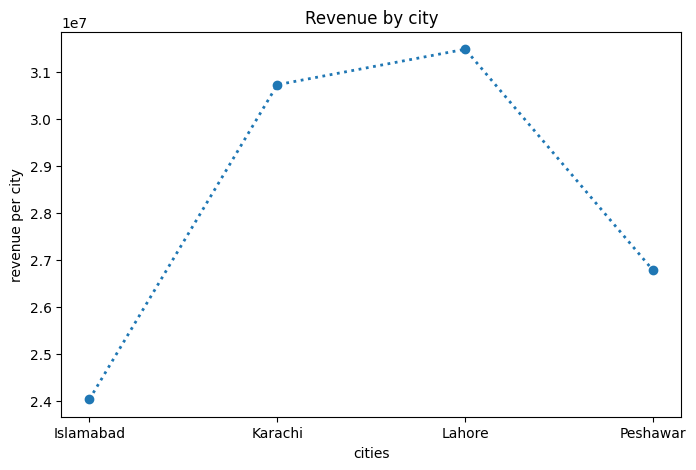

In [15]:
import matplotlib.pyplot  as plt
plt.figure(figsize=(8, 5))
plt.plot(total_revenue_city,linestyle=":",marker="o",linewidth=2)
plt.title("Revenue by city")
plt.xlabel("cities")
plt.ylabel("revenue per city")
plt.show()
